<a href="https://colab.research.google.com/github/Lichtphyz/Gesture_recognition/blob/master/CartPole_DQN_mod_better_eval.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## RL Learning, Problem Set #2, Q2
#### Daniel Licht


# Selected Mofification of the Environment
## Lets make the pole shorter (0.5 --> 0.2)

IMPORTANT NOTE ABOUT THIS SIMULATION:

My human experience says longer should be easier, but that's without the bang/bang action set constrains of step motions and the fixed force/velocity size we have here (we can't move our hand faster/further).

Adjustments to the scenario could also be made, but to keep things simple, I'm testing just shortening the pole length, which resulted in a somewhat easier balance problem for the model.

*note:*  
*I created a simpler version of this notebook initially, but it drove me crazy that we were evaluating the 'final policy' of the model, instead of the 'best policy', and that so very much of the end behavior and evaluation was stocastic as a result.*

*So I took some extra time and learned that EvalCallback() is generally used for this, and used it to impliment an evaluation of the 'best policy' instead (this required quite a few changes, but not a total re-work), as I imagine would be the more normal practice when doing RL for real.*

*I will share the simpler version of this NB as well, as that version I had no LLM assistance from and I think it satisfies the assignment requirements, but really this one is a lot better methodologically speaking, but I did use Claude to point me to the places to make changes to impliment EvalCallback(), and point my eval plots and video to the new 'best model' instead of the original 'final model'.*

# MECH 262: Gymnasium + Stable-Baselines3

## CartPole with DQN

This Colab notebook shows how to use Gymnasium environments with Stable-Baselines3 baseline algorithms.

Modified to explore modifying the envirnoment

## 1. Install packages

We need Gymnasium for environments, Stable-Baselines3 for RL algorithms, and imageio for saving videos.

In [27]:
!pip install gymnasium[classic-control] stable-baselines3 imageio

## 2. Import packages

In [28]:
import gymnasium as gym
from stable_baselines3 import DQN
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.monitor import load_results
from stable_baselines3.common.results_plotter import load_results, plot_results
from stable_baselines3.common.results_plotter import ts2xy, window_func
from stable_baselines3.common.evaluation import evaluate_policy

import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [29]:
def summarize_gym(env, model, max_steps = 1000, filename = "session_dqn.mp4"):
  import imageio
  from IPython.display import Video

  obs, info = env.reset()
  frames = []
  obs_log = []
  reward_log = []
  terminated_log = []

  for step in range(max_steps):
      frames.append(env.render())

      action, _ = model.predict(obs, deterministic=True)
      obs, reward, terminated, truncated, info = env.step(action)

      obs_log.append(obs)
      reward_log.append(reward)
      terminated_log.append(terminated)

      if terminated or truncated:
          break

  env.close()

  imageio.mimsave(filename, frames, fps=30)
  display(Video(filename, embed=True))
  return obs_log, reward_log, terminated_log, filename

In [30]:
# set up a couple logging folders
log_dir_1 = "/content/tmp/gym/run1_baseline/"
log_dir_2 = "/content/tmp/gym/run2_long_pole/"
os.makedirs(log_dir_1, exist_ok=True)
os.makedirs(log_dir_2, exist_ok=True)

In [31]:
from stable_baselines3.common.callbacks import EvalCallback
from gymnasium.wrappers import TimeLimit

# ---- shared eval settings across all conditions ----
EVAL_FREQ = 2000       # steps between evaluations
N_EVAL_EPISODES = 20   # episodes averaged per evaluation

N_steps = 100000
rand_seed = 42

## 3. Create a Gymnasium environment

Important step



In [32]:
env = gym.make("CartPole-v1")
print("Observation space:", env.observation_space)
print("Action space:", env.action_space)

Observation space: Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
Action space: Discrete(2)


## 4. CartPole observation and actions

The observation is:

$$s=[x, \dot{x}, \theta, \dot{\theta}]$$

where `x` is cart position, `x_dot` is cart velocity, `theta` is pole angle, and `theta_dot` is pole angular velocity.

The actions are:

- `0`: push left
- `1`: push right

What is the reward?

## 5. Train a DQN agent.
What do the DQN options mean?

- `MlpPolicy`: use a fully connected neural network.
- `learning_rate`: gradient descent step size.
- `buffer_size`: number of transitions stored in replay memory.
- `learning_starts`: how many transitions to collect before learning begins.
- `batch_size`: number of replay samples used per update.
- `gamma`: discount factor for future reward.
- `exploration_fraction`: fraction of training over which exploration decays.
- `exploration_final_eps`: final epsilon for epsilon-greedy exploration.

In [33]:
# env = gym.make("CartPole-v1")
raw_env = gym.make("CartPole-v1")
env = Monitor(raw_env, log_dir_1) # The monitored instance must be passed to the model
eval_env_1 = Monitor(gym.make("CartPole-v1"))   # separate instance, same env type

eval_callback_1 = EvalCallback(
    eval_env_1,
    best_model_save_path=log_dir_1 + "best_model/",
    log_path=log_dir_1,
    eval_freq=EVAL_FREQ,
    n_eval_episodes=N_EVAL_EPISODES,
    deterministic=True,
)

model = DQN(
    "MlpPolicy",
    env,
    learning_rate=1e-3, #1e-3,
    buffer_size=30_000,
    learning_starts=1000,
    batch_size=64,
    gamma=0.99,
    exploration_fraction=0.2,
    exploration_final_eps=0.02,
    verbose=0,
    seed=rand_seed,
)
model.learn(total_timesteps=N_steps, callback=eval_callback_1, progress_bar=True)

# load the checkpoint that scored best during training
best_model_1 = DQN.load(log_dir_1 + "best_model/best_model")

model.save("dqn_cartpole")
env.close()

Output()

/usr/local/lib/python3.12/dist-packages/ipywidgets/widgets/widget_output.py:111: DeprecationWarning: 
Kernel._parent_header is deprecated in ipykernel 6. Use .get_parent()
  if ip and hasattr(ip, 'kernel') and hasattr(ip.kernel, '_parent_header'):

Eval num_timesteps=2000, episode_reward=13.00 +/- 1.52

Eval num_timesteps=4000, episode_reward=11.15 +/- 1.28

Episode length: 11.15 +/- 1.28

...

Episode length: 114.85 +/- 3.17

Eval num_timesteps=98000, episode_reward=108.20 +/- 2.98

Episode length: 108.20 +/- 2.98

Eval num_timesteps=100000, episode_reward=132.80 +/- 13.05

Episode length: 132.80 +/- 13.05

In [34]:
# Verify the file actually exists right now
print("Files in directory:", os.listdir(log_dir_1))

Files in directory: ['best_model', 'monitor.csv', 'evaluations.npz']


In [35]:
# Load and verify
df_1 = load_results(log_dir_1)
print(df_1[["r", "l", "t"]].tail())

# Render the plot inside your Colab notebook
# plot_results([log_dir], num_timesteps=N_steps, x_axis="timesteps", task_name="DQN CartPole")

          r    l           t
1672  112.0  112  185.187311
1673  101.0  101  185.289340
1674  111.0  111  185.397607
1675  112.0  112  185.516751
1676  115.0  115  185.651730


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


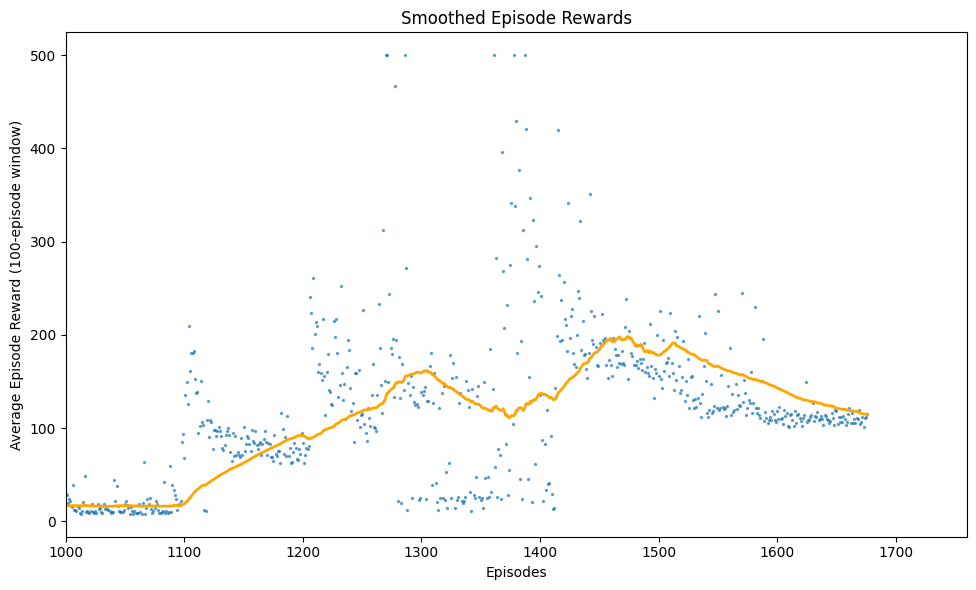

In [36]:
# Convert dataframe (x=timesteps, y=episodic return)
# x, y = ts2xy(df, "timesteps")
x, y = ts2xy(df_1, "episodes")

# Plot raw data
plt.figure(figsize=(10, 6))
plt.subplot(1, 1, 1)
plt.scatter(x, y, s=2, alpha=0.6)
plt.xlabel("Timesteps")
plt.ylabel("Episode Reward")
plt.title("Raw Episode Rewards")

# Plot smoothed data with custom window
# plt.subplot(2, 1, 2)
if len(x) >= 50:  # Only smooth if we have enough data
    x_smooth, y_smooth = window_func(x, y, 100, np.mean)
    plt.plot(x_smooth, y_smooth, linewidth=2, color="orange")
    plt.xlabel("Episodes")
    plt.ylabel("Average Episode Reward (100-episode window)")
    plt.title("Smoothed Episode Rewards")

plt.tight_layout()
plt.xlim(1000)
plt.show()

## 6. Visualize the trained policy in Colab


In [37]:
env = gym.make("CartPole-v1", render_mode="rgb_array")
obs_log, reward_log, terminated_log, filename = summarize_gym(env, best_model_1 )

In [38]:
len(reward_log)

500

Run Evaluation

/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/evaluation.py:71: UserWarning: Evaluation environment is not wrapped with a ``Monitor`` wrapper. This may result in reporting modified episode lengths and rewards, if other wrappers happen to modify these. Consider wrapping environment first with ``Monitor`` wrapper.
  warnings.warn(


Individual Episode Rewards: [500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 474.0, 500.0, 500.0, 420.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 451.0, 500.0, 500.0, 500.0, 500.0, 422.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 355.0, 432.0, 500.0, 500.0, 500.0, 500.0, 500.0, 387.0, 500.0, 500.0, 349.0, 500.0, 500.0, 500.0, 500.0, 500.0, 420.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 464.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 404.0, 500.0, 500.0, 500.0, 500.0]
Mean Reward: 490.78


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Text(0.5, 1.0, 'Evaluation Reward (balance time)')

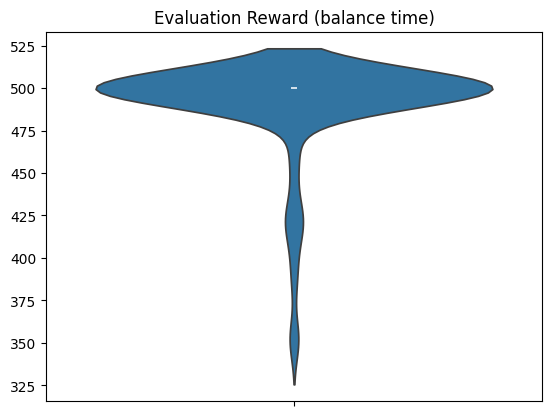

In [39]:
# env = gym.make("CartPole-v1")
# model = DQN.load("dqn_cartpole")

# return_episode_rewards=True outputs raw individual scores instead of averages
rewards, lengths = evaluate_policy(
    best_model_1,
    env,
    n_eval_episodes=100,
    deterministic=True,
    return_episode_rewards=True
)

rewards_list = []
for n in rewards:
  rewards_list.append(float(n))

print("Individual Episode Rewards:", rewards_list)
print("Mean Reward:", sum(rewards) / len(rewards))

sns.violinplot(rewards_list,)
plt.title("Evaluation Reward (balance time)")


# Modify the Environment
## Lets make the pole shorter (0.5 --> 0.2)!

IMPORTANT NOTE ABOUT THIS SIMULATION:

My human experience says longer should be easier, but that's without the bang/bang action set constrains of step motions and the fixed force/velocity size we have here (we can't move our hand faster/further).

Adjustments to the scenario could also be made, but to keep things simple, I'm testing just shortening the pole length, which resulted in a somewhat easier balance problem for the model.

In [40]:
# make a copy of the env to edit:
# !cp /usr/local/lib/python3.12/dist-packages/gymnasium/envs/classic_control/cartpole.py ./my_cartpole_1.py

#  The file was modified to make the Pole shorter than normal


In [41]:
from my_cartpole_1 import CartPoleEnv
import importlib, my_cartpole_1
importlib.reload(my_cartpole_1)

<module 'my_cartpole_1' from '/content/my_cartpole_1.py'>

In [42]:
# env = gym.make("CartPole-v1")
raw_env = TimeLimit(my_cartpole_1.CartPoleEnv(), max_episode_steps=500)
env = Monitor(raw_env, log_dir_2)
eval_env_2 = Monitor(TimeLimit(my_cartpole_1.CartPoleEnv(), max_episode_steps=500))

eval_callback_2 = EvalCallback(
    eval_env_2,
    best_model_save_path=log_dir_2 + "best_model/",
    log_path=log_dir_2,
    eval_freq=EVAL_FREQ,
    n_eval_episodes=N_EVAL_EPISODES,
    deterministic=True,
)

model2 = DQN(
    "MlpPolicy",
    env,
    learning_rate=1e-3, #1e-3,
    buffer_size=30_000,
    learning_starts=1000,
    batch_size=64,
    gamma=0.99,
    exploration_fraction=0.2,
    exploration_final_eps=0.02,
    verbose=0,
    seed=rand_seed,
)

model2.learn(total_timesteps=N_steps, callback=eval_callback_2, progress_bar=True)

best_model_2 = DQN.load(log_dir_2 + "best_model/best_model")

model2.save("dqn_cartpole_new")
env.close()

Output()

/usr/local/lib/python3.12/dist-packages/ipywidgets/widgets/widget_output.py:111: DeprecationWarning: 
Kernel._parent_header is deprecated in ipykernel 6. Use .get_parent()
  if ip and hasattr(ip, 'kernel') and hasattr(ip.kernel, '_parent_header'):

Eval num_timesteps=2000, episode_reward=7.25 +/- 0.70

Episode length: 7.25 +/- 0.70

New best mean reward!

...

New best mean reward!

Eval num_timesteps=98000, episode_reward=500.00 +/- 0.00

Episode length: 500.00 +/- 0.00

Eval num_timesteps=100000, episode_reward=500.00 +/- 0.00

Episode length: 500.00 +/- 0.00

In [43]:
df_2 = load_results(log_dir_2)
print(df_2[["r", "l", "t"]].tail())

          r    l           t
2380  500.0  500  203.827391
2381  500.0  500  210.947468
2382  500.0  500  211.498656
2383  500.0  500  212.043172
2384  200.0  200  212.252159


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


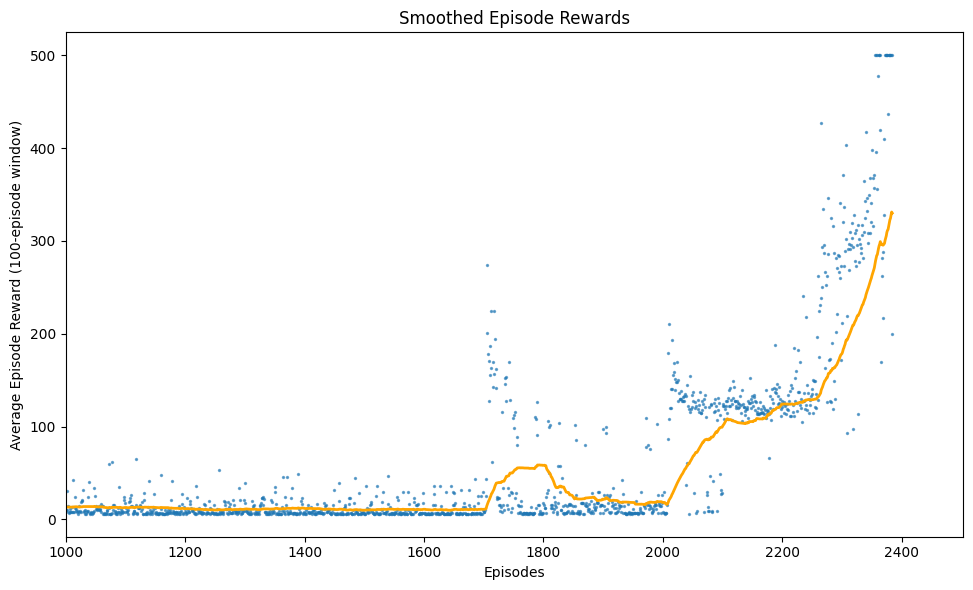

In [44]:
x, y = ts2xy(df_2, "episodes")

# Plot raw data
plt.figure(figsize=(10, 6))
plt.subplot(1, 1, 1)
plt.scatter(x, y, s=2, alpha=0.6)
plt.xlabel("Timesteps")
plt.ylabel("Episode Reward")
plt.title("Raw Episode Rewards")

# Plot smoothed data with custom window
# plt.subplot(2, 1, 2)
if len(x) >= 50:  # Only smooth if we have enough data
    x_smooth, y_smooth = window_func(x, y, 100, np.mean)
    plt.plot(x_smooth, y_smooth, linewidth=2, color="orange")
    plt.xlabel("Episodes")
    plt.ylabel("Average Episode Reward (100-episode window)")
    plt.title("Smoothed Episode Rewards")

plt.tight_layout()
plt.xlim(1000)
plt.show()

In [45]:
# env = my_cartpole_1.CartPoleEnv(render_mode="rgb_array")
env = TimeLimit(my_cartpole_1.CartPoleEnv(render_mode="rgb_array"), max_episode_steps=500)
obs_log, reward_log, terminated_log, filename = summarize_gym(env, best_model_2 , filename="session_dqn_long.mp4")

/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/evaluation.py:71: UserWarning: Evaluation environment is not wrapped with a ``Monitor`` wrapper. This may result in reporting modified episode lengths and rewards, if other wrappers happen to modify these. Consider wrapping environment first with ``Monitor`` wrapper.
  warnings.warn(


Individual Episode Rewards: [500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 453.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 486.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 468.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0]
Mean Reward: 499.07


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Text(0.5, 1.0, 'Evaluation Reward (balance time)')

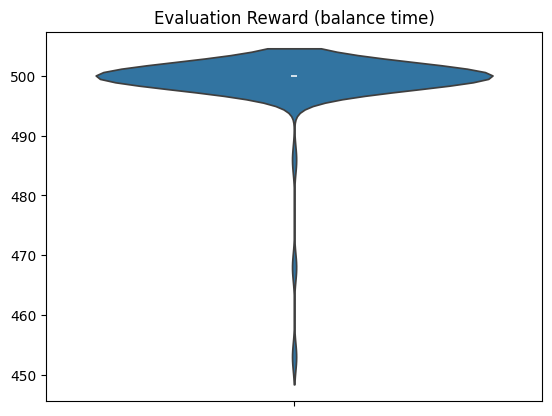

In [46]:
# return_episode_rewards=True outputs raw individual scores instead of averages
rewards, lengths = evaluate_policy(
    best_model_2,
    env,
    n_eval_episodes=100,
    deterministic=True,
    return_episode_rewards=True
)

rewards_list_2 = []
for n in rewards:
  rewards_list_2.append(float(n))

print("Individual Episode Rewards:", rewards_list_2)
print("Mean Reward:", sum(rewards) / len(rewards))

sns.violinplot(rewards_list_2,)
plt.title("Evaluation Reward (balance time)")

/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/evaluation.py:71: UserWarning: Evaluation environment is not wrapped with a ``Monitor`` wrapper. This may result in reporting modified episode lengths and rewards, if other wrappers happen to modify these. Consider wrapping environment first with ``Monitor`` wrapper.
  warnings.warn(


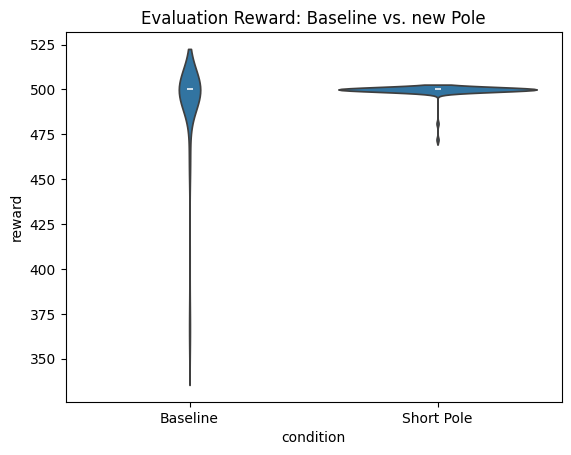

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [47]:
eval_env1 = gym.make("CartPole-v1")
eval_env2 = TimeLimit(my_cartpole_1.CartPoleEnv(), max_episode_steps=500)

rewards1, _ = evaluate_policy(best_model_1, eval_env1, n_eval_episodes=100, deterministic=True, return_episode_rewards=True)
rewards2, _ = evaluate_policy(best_model_2, eval_env2, n_eval_episodes=100, deterministic=True, return_episode_rewards=True)

import pandas as pd
compare_df = pd.DataFrame({
    "reward": list(rewards1) + list(rewards2),
    "condition": ["Baseline"]*len(rewards1) + ["Short Pole"]*len(rewards2)
})

sns.violinplot(data=compare_df, x="condition", y="reward")
plt.title("Evaluation Reward: Baseline vs. new Pole")
plt.show()

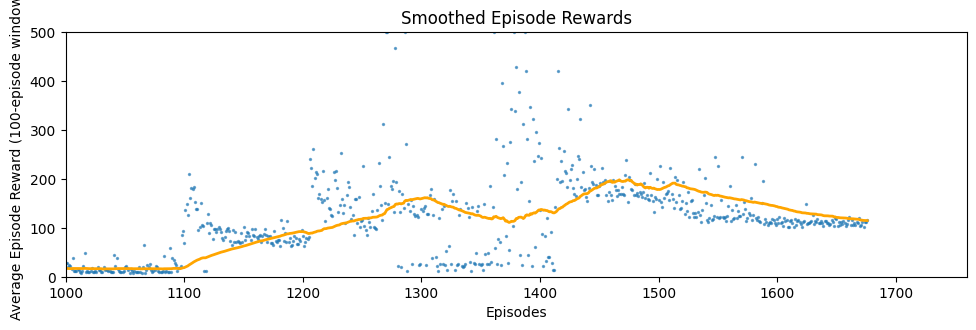

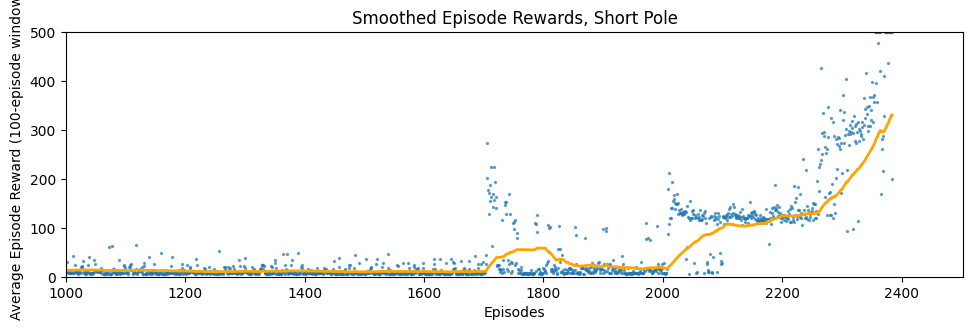

In [48]:
x, y = ts2xy(df_1, "episodes")
x2, y2 = ts2xy(df_2, "episodes")
y_max = max(max(y), max(y2))

# Plot raw data
plt.figure(figsize=(10, 6))
plt.subplot(2, 1, 1)
plt.scatter(x, y, s=2, alpha=0.6)
plt.xlabel("Timesteps")
plt.ylabel("Episode Reward")
plt.title("Raw Episode Rewards")

# Plot smoothed data with custom window
# plt.subplot(2, 1, 2)
if len(x) >= 50:  # Only smooth if we have enough data
    x_smooth, y_smooth = window_func(x, y, 100, np.mean)
    plt.plot(x_smooth, y_smooth, linewidth=2, color="orange")
    plt.xlabel("Episodes")
    plt.ylabel("Average Episode Reward (100-episode window)")
    plt.title("Smoothed Episode Rewards")

plt.tight_layout()
plt.xlim(1000)
plt.ylim(0,y_max)

# Plot raw data
plt.figure(figsize=(10, 6))
plt.subplot(2, 1, 1)
plt.scatter(x2, y2, s=2, alpha=0.6)
plt.xlabel("Timesteps")
plt.ylabel("Episode Reward")
plt.title("Raw Episode Rewards")

# Plot smoothed data with custom window
# plt.subplot(2, 1, 2)
if len(x) >= 50:  # Only smooth if we have enough data
    x_smooth, y_smooth = window_func(x2, y2, 100, np.mean)
    plt.plot(x_smooth, y_smooth, linewidth=2, color="orange")
    plt.xlabel("Episodes")
    plt.ylabel("Average Episode Reward (100-episode window)")
    plt.title("Smoothed Episode Rewards, Short Pole")

plt.tight_layout()
plt.xlim(1000)
plt.ylim(0,y_max)
plt.show()

Shortening of the pole appears to have made the task somewhat easier once enough practice steps have been taken (pole mass, and cart's mass and force capabilities remain the same).  It does however seem to take the model longer on average to start making significant progress on the short-pole case, but once it does the results end up better.

We see that the distribution of late training and evaluation scores consistently clusters higher for the short-pole scenario.


#Better best-model comparison:

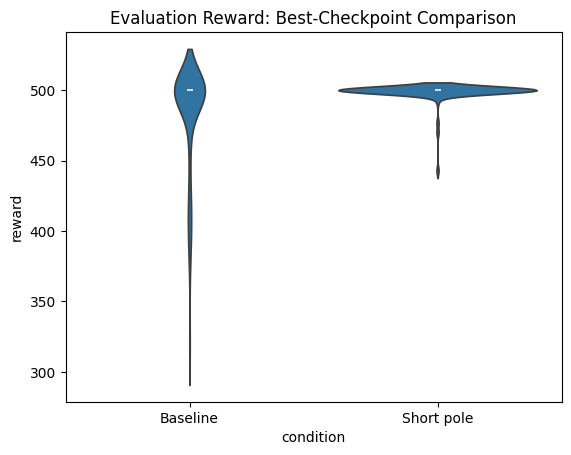

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [49]:
eval_env1_final = Monitor(gym.make("CartPole-v1"))
eval_env2_final = Monitor(TimeLimit(my_cartpole_1.CartPoleEnv(), max_episode_steps=500))

rewards1, _ = evaluate_policy(best_model_1, eval_env1_final,
                               n_eval_episodes=100, deterministic=True,
                               return_episode_rewards=True)
rewards2, _ = evaluate_policy(best_model_2, eval_env2_final,
                               n_eval_episodes=100, deterministic=True,
                               return_episode_rewards=True)

compare_df = pd.DataFrame({
    "reward": list(rewards1) + list(rewards2),
    "condition": ["Baseline"]*len(rewards1) + ["Short pole"]*len(rewards2),
})
sns.violinplot(data=compare_df, x="condition", y="reward")
plt.title("Evaluation Reward: Best-Checkpoint Comparison")
plt.show()

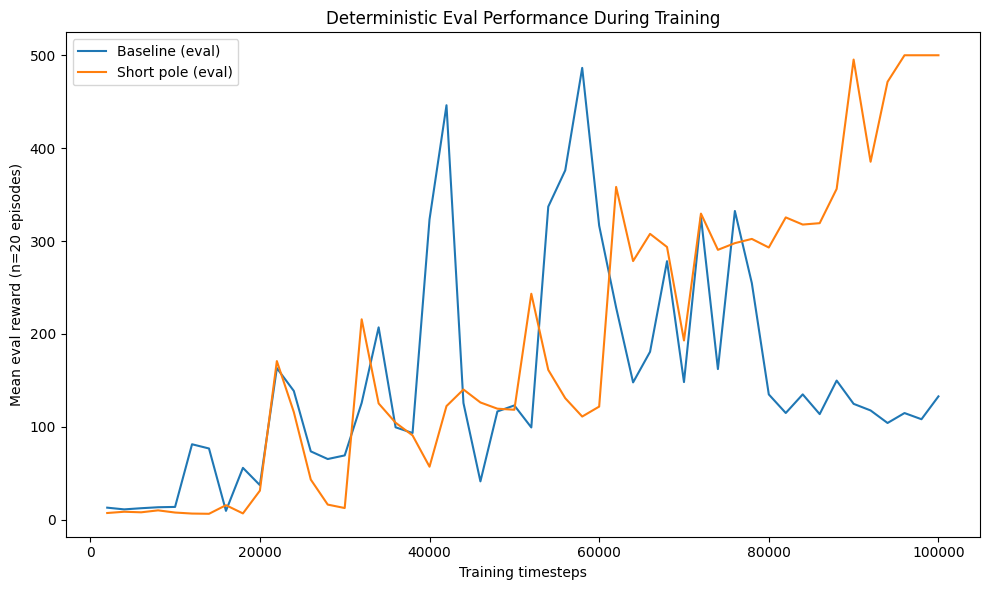

In [50]:
data_1 = np.load(log_dir_1 + "evaluations.npz")
data_2 = np.load(log_dir_2 + "evaluations.npz")

plt.figure(figsize=(10, 6))
plt.plot(data_1["timesteps"], data_1["results"].mean(axis=1), label="Baseline (eval)")
plt.plot(data_2["timesteps"], data_2["results"].mean(axis=1), label="Short pole (eval)")
plt.xlabel("Training timesteps")
plt.ylabel("Mean eval reward (n=20 episodes)")
plt.title("Deterministic Eval Performance During Training")
plt.legend()
plt.tight_layout()
plt.show()

## Questions:
(a) Easiest: short pole (length=0.2) — higher eval reward, higher training curve.

(b) Most difficult: Baseline (length=0.5) was more difficult than the shorter pole, but I also tested a longer pole, and that was significantly harder still, I believe because the cart movement force (and therefore size) was not ramped up alongside the length.

(c) Effect on final performance: shortening the pole raised both training-curve performance and 100-episode eval reward/mean relative to baseline.  Though in many cases it took >50,000 steps before it pulled ahead of the baseline model.

(d) Why: This cartpole problem is very constrained, with a fixed action space of 'move right'/'move left' a set amount.  This significantly changes the problem from human hand pole-balancing (where longer is easier).  Instead, we have a situation where the cart movement is effectly constant, so if the pole is shortened, then the cart's actions are proportionally larger compared to it, thus making it easier to influcence the rod and learn to control it.  For a longer rod, the fixed cart motions would have a proportionally smaller impact on the rod, making it harder to learn and prevent from falling once motion has started.  Humans could ramp up the motion in proportion (perhaps at the cost of precision), but this cart is specifically set up not to.

my_cartpole_1.py parameters:
```
    def __init__(
        self, sutton_barto_reward: bool = False, render_mode: str | None = None
    ):
        self._sutton_barto_reward = sutton_barto_reward

        self.gravity = 9.8
        self.masscart = 1.0
        self.masspole = 0.1
        self.total_mass = self.masspole + self.masscart
        self.length = 0.2  # actually half the pole's length <-- THIS WAS CHANGED FROM 0.5
        self.polemass_length = self.masspole * self.length
        self.force_mag = 10.0
        self.tau = 0.02  # seconds between state updates
        self.kinematics_integrator = "euler"
